# Importação das bibliotecas

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Acessando a base limpa

In [2]:
df = pd.read_csv('../data/processed/pede_consolidado_limpo.csv')

# Questões

Questão 1: Adequação de Nível (IAN)

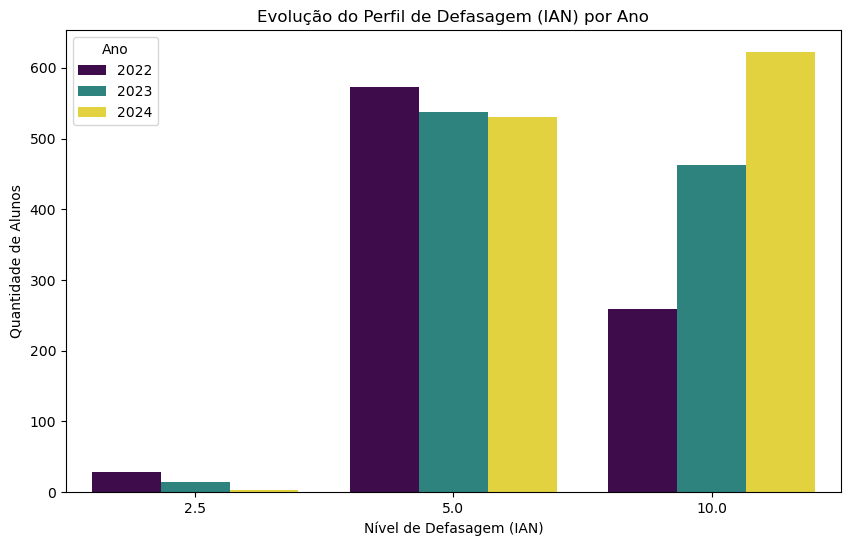

In [3]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='IAN', hue='ANO_LETIVO', palette='viridis')
plt.title('Evolução do Perfil de Defasagem (IAN) por Ano')
plt.xlabel('Nível de Defasagem (IAN)')
plt.ylabel('Quantidade de Alunos')
plt.legend(title='Ano')
plt.show()

Questão 2: Desempenho Acadêmico (IDA)

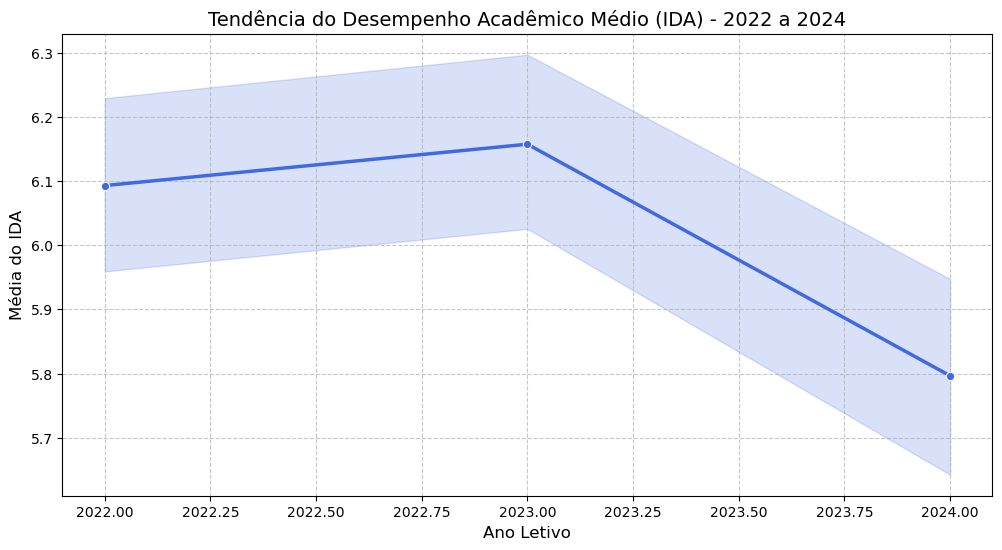

Média de desempenho (IDA) por ano:
ANO_LETIVO
2022    6.092907
2023    6.157396
2024    5.796497
Name: IDA, dtype: float64


In [4]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df, x='ANO_LETIVO', y='IDA', marker='o', color='royalblue', linewidth=2.5)

plt.title('Tendência do Desempenho Acadêmico Médio (IDA) - 2022 a 2024', fontsize=14)
plt.xlabel('Ano Letivo', fontsize=12)
plt.ylabel('Média do IDA', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("Média de desempenho (IDA) por ano:")
print(df.groupby('ANO_LETIVO')['IDA'].mean())

Questão 3: Engajamento (IEG)

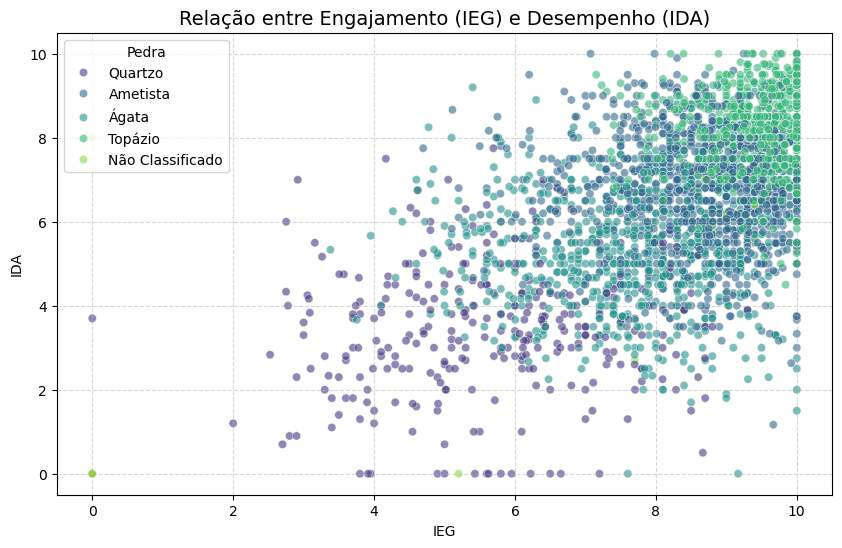

In [5]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='IEG', y='IDA', hue='Pedra', palette='viridis', alpha=0.6)
plt.title('Relação entre Engajamento (IEG) e Desempenho (IDA)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Questões 4 e 8: Autoavaliação (IAA) e Multidimensionalidade

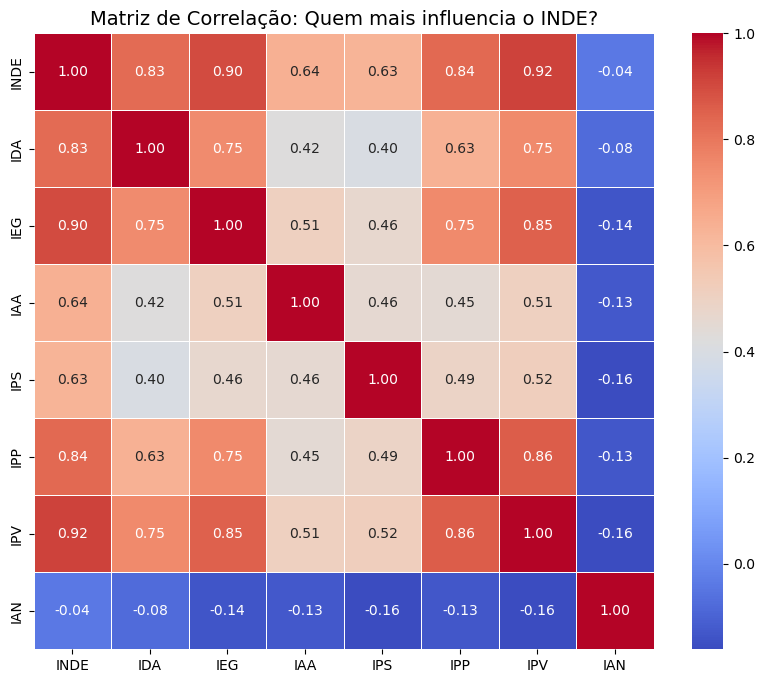

In [6]:
plt.figure(figsize=(10, 8))
cols_indicadores = ['INDE', 'IDA', 'IEG', 'IAA', 'IPS', 'IPP', 'IPV', 'IAN']
correlation = df[cols_indicadores].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlação: Quem mais influencia o INDE?', fontsize=14)
plt.show()

Questões 5, 6 e 7: Aspectos Pscicossocias (IPS), Aspectos Pscicopedágogicos (IPP) e Ponto de Virada (IPV)

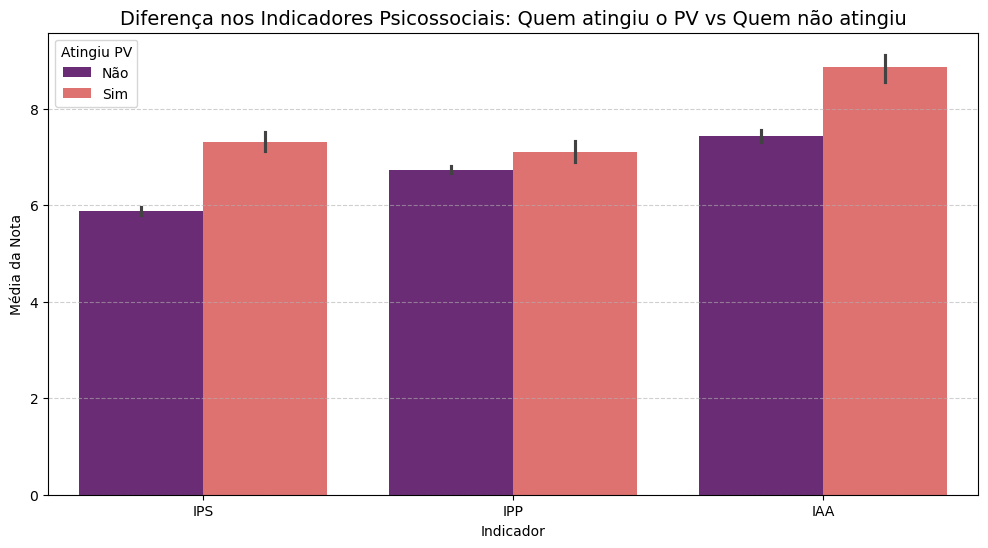

In [7]:
plt.figure(figsize=(12, 6))

indicadores_sociais = ['IPS', 'IPP', 'IAA']
df_melted = df.melt(id_vars=['Atingiu PV'], value_vars=indicadores_sociais, 
                    var_name='Indicador', value_name='Nota')

sns.barplot(data=df_melted, x='Indicador', y='Nota', hue='Atingiu PV', palette='magma')

plt.title('Diferença nos Indicadores Psicossociais: Quem atingiu o PV vs Quem não atingiu', fontsize=14)
plt.ylabel('Média da Nota')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

Preparação questão 9: Previsão de Risco

In [8]:
baixo_desempenho = df[df['IDA'] < 5]['IPS'].mean()
alto_desempenho = df[df['IDA'] >= 5]['IPS'].mean()

print(f"Média de IPS (Psicossocial) de alunos com IDA baixo (<5): {baixo_desempenho:.2f}")
print(f"Média de IPS (Psicossocial) de alunos com IDA alto (>=5): {alto_desempenho:.2f}")

Média de IPS (Psicossocial) de alunos com IDA baixo (<5): 5.06
Média de IPS (Psicossocial) de alunos com IDA alto (>=5): 6.25


Questão 10: Efetividade do Programa

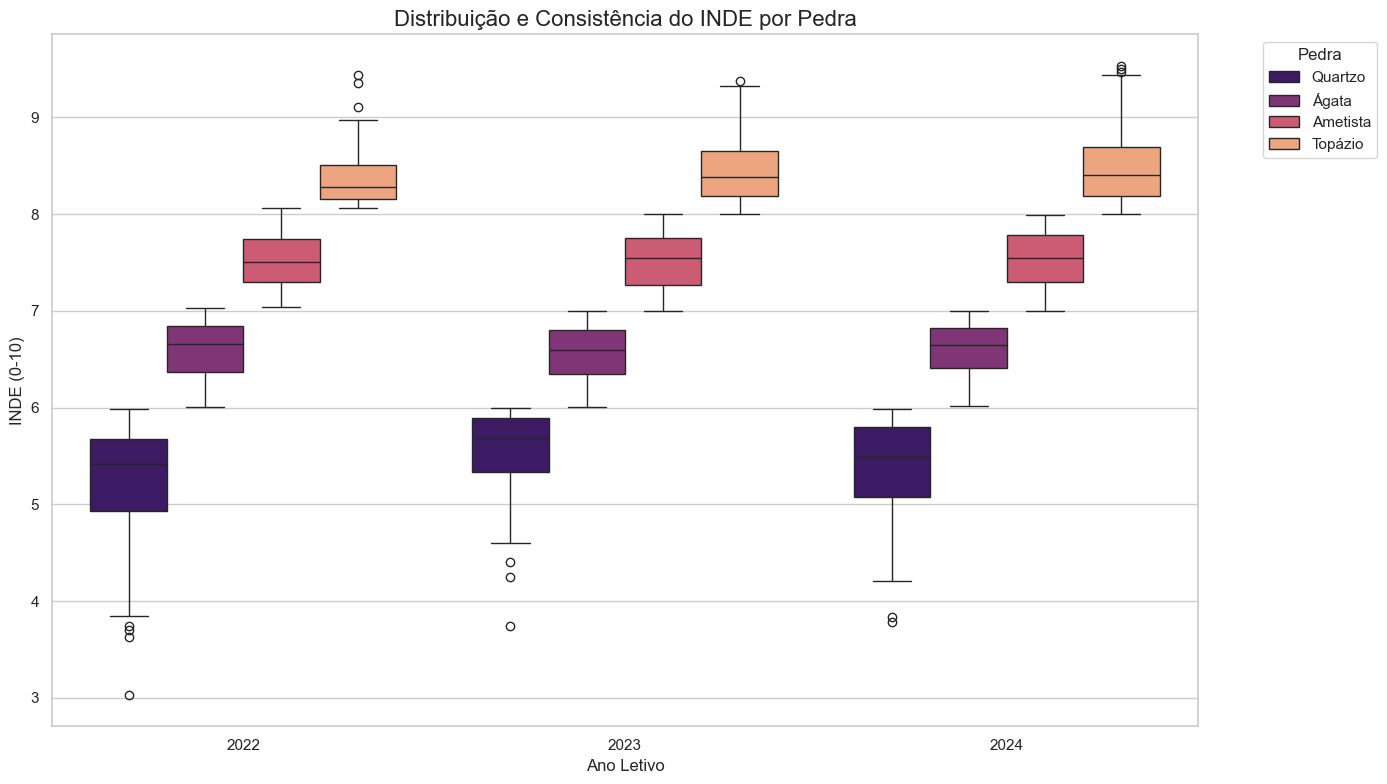

In [11]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df, 
    x='ANO_LETIVO', 
    y='INDE', 
    hue='Pedra', 
    palette='magma',
    hue_order=['Quartzo', 'Ágata', 'Ametista', 'Topázio']
)

plt.title('Distribuição e Consistência do INDE por Pedra', fontsize=16)
plt.ylabel('INDE (0-10)')
plt.xlabel('Ano Letivo')
plt.legend(title='Pedra', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()